In [38]:
import joblib
import numpy as np
import matplotlib.pyplot as plt
import json

In [186]:
## TO CHANGE

TIMPORTANCE_LOAD_DIR = "../experiments/reader_context_noising_with_scores (exp #5)/with_relevant_contexts_without_score (exp #5.4)/mlqa/vi/logs/v3.1.1.attn/gen_metainfo"
TIMPORTANCE_FILENAME = "timportance"
PLOT_SAVE_FILENAME = "averaged_timportance({layer}_{merge_by}).png"
SEQLEN_STATS_FILENAME = "sequences_len_stats.json"

In [194]:
# TO CHANGE
MODEL_NAME = 'Llama3.1 8B'
DATASET_NAME = 'mlqa_vi'
REL_POSITION = 'MIDDLE'
SAMPLES = 2000
LAYER_NUMS = [0,1,15,31]
MERGE_BY = 'columns'

In [195]:
timportance = joblib.load(f"{TIMPORTANCE_LOAD_DIR}/{TIMPORTANCE_FILENAME}")

In [196]:
sequences_len = [len(timportance[i][LAYER_NUMS[0]][MERGE_BY]) for i in range(SAMPLES)]
seqlen_stats = {
    "min": int(np.min(sequences_len)), 
    "max": int(np.max(sequences_len)),
    "mean": float(np.mean(sequences_len)),
    "median": int(np.median(sequences_len)),
    "std": round(float(np.std(sequences_len)),2)
}
print(seqlen_stats)

{'min': 481, 'max': 2191, 'mean': 1189.189, 'median': 1173, 'std': 273.44}


In [197]:
with open(f"{TIMPORTANCE_LOAD_DIR}/{SEQLEN_STATS_FILENAME}", 'w', encoding='utf-8') as fp:
    fp.write(json.dumps(seqlen_stats, ensure_ascii=False, indent=1))

In [198]:
y_es = []
for layer_n in LAYER_NUMS:
    y = []
    max_len_exceeded = False
    cur_token_idx = -1
    while not max_len_exceeded:
        cur_token_idx += 1
        tmp_y = []
        for i in range(SAMPLES):
            try:
                tmp_y.append(timportance[i][layer_n][MERGE_BY][cur_token_idx])
            except IndexError:
                pass
        
        if len(tmp_y) < 1:
            max_len_exceeded = True
        else:
            y.append(np.mean(tmp_y))

    y_es.append(y)

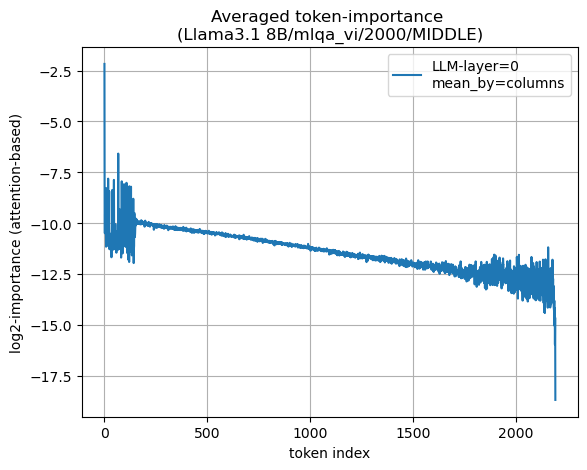

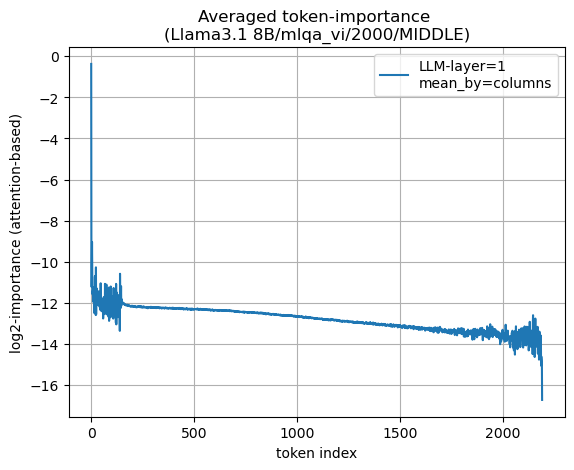

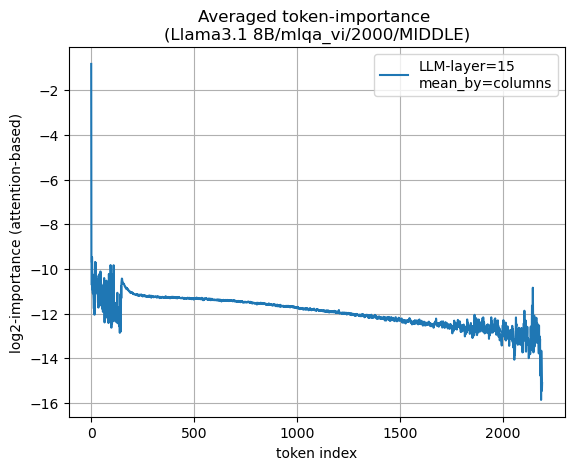

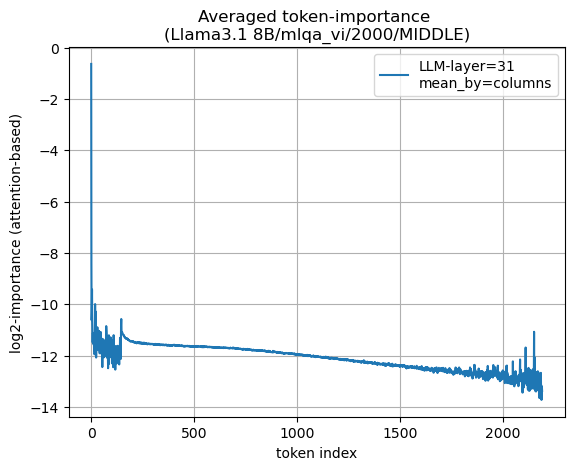

In [199]:
for y, layer_n in zip(y_es, LAYER_NUMS):
    CUR_PLOT_FILENAME = PLOT_SAVE_FILENAME.format(layer=layer_n, merge_by=MERGE_BY)
    plt.plot(list(range(len(y))), np.log2(np.array(y)), label=f'LLM-layer={layer_n}\nmean_by={MERGE_BY}')
    plt.grid()
    plt.xlabel("token index")
    plt.ylabel("log2-importance (attention-based)")
    plt.title(f"Averaged token-importance \n({MODEL_NAME}/{DATASET_NAME}/{SAMPLES}/{REL_POSITION})")
    plt.legend()
    plt.savefig(f"{TIMPORTANCE_LOAD_DIR}/{CUR_PLOT_FILENAME}", bbox_inches='tight')
    plt.show()

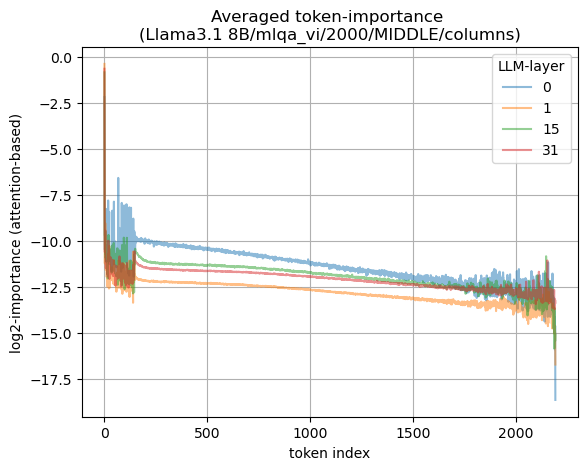

In [200]:
STACKED_PLOT_FILENAME = f"stacked_averaged_timportance({MERGE_BY}).png"
for y, layer_n in zip(y_es, LAYER_NUMS):
    plt.plot(list(range(len(y))), np.log2(np.array(y)), label=f'{layer_n}', alpha=0.5)
plt.grid()
plt.xlabel("token index")
plt.ylabel("log2-importance (attention-based)")
plt.title(f"Averaged token-importance \n({MODEL_NAME}/{DATASET_NAME}/{SAMPLES}/{REL_POSITION}/{MERGE_BY})")
plt.legend(title='LLM-layer')
plt.savefig(f"{TIMPORTANCE_LOAD_DIR}/{STACKED_PLOT_FILENAME}", bbox_inches='tight')
plt.show()